In [1]:
import logging

logFileName='Lx'

logger = logging.getLogger(logFileName)  

logFile= logFileName+'.log' 

loglevel = logging.DEBUG
logging.basicConfig(filename=logFile
                        ,filemode='w'
                        ,level=loglevel
                        ,format="%(asctime)s ; %(name)-60s ; %(levelname)-7s ; %(message)s")    

fileHandler = logging.FileHandler(logFile)     

logger.addHandler(fileHandler)

consoleHandler = logging.StreamHandler()
consoleHandler.setFormatter(logging.Formatter("%(levelname)-7s ; %(message)s"))
consoleHandler.setLevel(logging.INFO)
logger.addHandler(consoleHandler)

In [2]:
import pandas as pd
import time
import re

In [3]:
pd.set_option('display.max_rows',1111)

In [4]:
import Lx
# from PT3S import Lx

## Initialisierung

In [5]:
zip7File=r'c:\Users\wolters\source\repos\PT3S\testdata\Lx\20201113_151238a - 6 Logs.7z'
logFile=r'c:\Users\wolters\source\repos\PT3S\testdata\Lx\20201113_0000003.log'

### mit Log

In [6]:
start = time.time()
lx=Lx.AppLog(logFile=logFile) # init with single log
end = time.time()
print(end - start)

36.27022671699524


### nochmal mit Log (wg. "Test" Detail restValues)

In [7]:
start = time.time()
lx=Lx.AppLog(logFile=logFile,parseRestvalues=True) # init with single log
end = time.time()
print(end - start)

73.61497473716736


### mit Zip (d.h. mit 1. Log in Zip)

In [8]:
start = time.time()
lx=Lx.AppLog(zip7File=zip7File) # init with 1st Log in zip
end = time.time()
print(end - start)

41.98305583000183


## mit Daten befuellen

### aus zip

In [9]:
start = time.time()
lx.addZip7File(zip7File) # data from zip
end = time.time()
dauer=end - start

In [10]:
print("6 logs benoetigen {!s:s} Sekunden".format(round(dauer,2)))
dauer400LogsinMinuten=round(dauer/6*400/60,2) # in einer Zip sind bei 1 GB ca. 400 Logs
print("400 logs benoetigen dann ca. {!s:s} Minuten".format(dauer400LogsinMinuten))
KalenderZeitProLogInMinuten=3.5 # Mittelwert
KalenderZeit400Logs=400*KalenderZeitProLogInMinuten
f=KalenderZeit400Logs/dauer400LogsinMinuten
print("Logs für 1 Kalendertag benoetigen dann in der Aufbereitung ca. {!s:s} Stunde(n)".format(round(24*60/f/60),2))

6 logs benoetigen 266.75 Sekunden
400 logs benoetigen dann ca. 296.38 Minuten
Logs für 1 Kalendertag benoetigen dann in der Aufbereitung ca. 5 Stunde(n)


In [11]:
lx.lookUpDf

,LogFile,FirstTime,LastTime
0,20201113_0000004.log,2020-11-13 14:24:54.973,2020-11-13 14:28:56.953
1,20201113_0000005.log,2020-11-13 14:28:56.952,2020-11-13 14:32:58.997
2,20201113_0000006.log,2020-11-13 14:32:58.995,2020-11-13 14:37:01.015
3,20201113_0000400.log,2020-11-14 16:30:34.386,2020-11-14 16:34:26.231
4,20201113_0000401.log,2020-11-14 16:34:26.229,2020-11-14 16:38:18.084
5,20201113_0000402.log,2020-11-14 16:38:18.083,2020-11-14 16:42:09.938


## Daten extrahieren

In [12]:
start = time.time()
df=lx.get() # data from zip - ohne Parameter alles; das ist i.d.R. viel zu viel fuer den Arbeitsspeicher
end = time.time()
dauer=end - start
print(dauer)

16.419259786605835


In [13]:
print("eine Kalenderzeit von {!s:s} Minuten benoetigt {!s:s} Minuten zum lesen".format(KalenderZeitProLogInMinuten*6,round(dauer/60,2)))
print("eine typische Analyse-Kalenderzeit von 30 Minuten benoetigt dann {!s:s} Minuten zum lesen".format(round(30*dauer/60/(KalenderZeitProLogInMinuten*6),2)))

eine Kalenderzeit von 21.0 Minuten benoetigt 0.27 Minuten zum lesen
eine typische Analyse-Kalenderzeit von 30 Minuten benoetigt dann 0.39 Minuten zum lesen


In [14]:
df.head()

,#LogTime,LogLevel,SubSystem,Direction,ProcessTime,ID,Value,ScenTime,State,Remark
0,2020-11-13 14:24:54.973,STD,LOGGING,nan,NaT,nan,NaN,2020-11-13 15:24:52,nan,Logfilesize of /home/3sconsult/Logs/20201113_1...
1,2020-11-13 14:24:54.975,STD,LOGGING,nan,NaT,nan,NaN,2020-11-13 15:24:52,nan,Free space in Log Directory: 195155144704
2,2020-11-13 14:24:55.000,INF,SQC,nan,NaT,nan,NaN,2020-11-13 15:24:53,nan,Starting cycle for 2020-11-13 15:24:53.000
3,2020-11-13 14:24:55.000,INF,SQC,nan,NaT,nan,NaN,2020-11-13 15:24:53,nan,Updating DFIDTs...
4,2020-11-13 14:24:55.027,STD,SQC,nan,NaT,nan,NaN,2020-11-13 15:24:53,nan,Status is 0


In [15]:
df.tail()

,#LogTime,LogLevel,SubSystem,Direction,ProcessTime,ID,Value,ScenTime,State,Remark
1074743,2020-11-14 16:42:09.760,INF,OPC UA,->,2020-11-14 16:42:09.760,Objects.FBG_MESSW.4_SV1_10_FT_01.In.MW.value,302.740380,2020-11-14 17:42:07,nan,Sensor: 1605372129098 Server: 1605372129098
1074744,2020-11-14 16:42:09.760,INF,OPC UA,->,2020-11-14 16:42:09.760,Objects.FBG_MESSW.6_BID_01_FT_01.In.MW.value,135.711097,2020-11-14 17:42:07,nan,Sensor: 1605372128731 Server: 1605372128731
1074745,2020-11-14 16:42:09.760,INF,OPC UA,->,2020-11-14 16:42:09.760,Objects.FBG_MESSW.6_BID_10_FT_01.In.MW.value,394.957643,2020-11-14 17:42:07,nan,Sensor: 1605372128934 Server: 1605372128934
1074746,2020-11-14 16:42:09.760,INF,OPC UA,->,2020-11-14 16:42:09.760,Objects.FBG_MESSW.6_SKV_10_PTI_01.In.MW.value,37.157869,2020-11-14 17:42:07,nan,Sensor: 1605372129367 Server: 1605372129367
1074747,2020-11-14 16:42:09.938,STD,LOGGING,nan,NaT,nan,NaN,2020-11-14 17:42:07,nan,Next Logfile: /home/3sconsult/Logs/20201113_15...


## Initialisierung mit H5

In [16]:
h5File=r'C:\Users\wolters\source\repos\PT3S\testdata\Lx\Log ab 2020 11 13 14 24 54.973000.h5'

In [17]:
start = time.time()
lx=Lx.AppLog(h5File=h5File) # init with H5 (init by "connection" to previuosly parsed Logs)
end = time.time()
print(end - start)

0.03889608383178711


In [18]:
lx.lookUpDf

,LogFile,FirstTime,LastTime
0,20201113_0000004.log,2020-11-13 14:24:54.973,2020-11-13 14:28:56.953
1,20201113_0000005.log,2020-11-13 14:28:56.952,2020-11-13 14:32:58.997
2,20201113_0000006.log,2020-11-13 14:32:58.995,2020-11-13 14:37:01.015
3,20201113_0000400.log,2020-11-14 16:30:34.386,2020-11-14 16:34:26.231
4,20201113_0000401.log,2020-11-14 16:34:26.229,2020-11-14 16:38:18.084
5,20201113_0000402.log,2020-11-14 16:38:18.083,2020-11-14 16:42:09.938


In [19]:
df.head()

,#LogTime,LogLevel,SubSystem,Direction,ProcessTime,ID,Value,ScenTime,State,Remark
0,2020-11-13 14:24:54.973,STD,LOGGING,nan,NaT,nan,NaN,2020-11-13 15:24:52,nan,Logfilesize of /home/3sconsult/Logs/20201113_1...
1,2020-11-13 14:24:54.975,STD,LOGGING,nan,NaT,nan,NaN,2020-11-13 15:24:52,nan,Free space in Log Directory: 195155144704
2,2020-11-13 14:24:55.000,INF,SQC,nan,NaT,nan,NaN,2020-11-13 15:24:53,nan,Starting cycle for 2020-11-13 15:24:53.000
3,2020-11-13 14:24:55.000,INF,SQC,nan,NaT,nan,NaN,2020-11-13 15:24:53,nan,Updating DFIDTs...
4,2020-11-13 14:24:55.027,STD,SQC,nan,NaT,nan,NaN,2020-11-13 15:24:53,nan,Status is 0


## einfache Teilmengen

In [20]:
start = time.time()
dfOPC=df[(df['SubSystem'].str.contains('^OPC')) & ~(df['Value'].isnull())]
dfOPC=dfOPC[['ProcessTime','ID','Value']]
dfOPC.rename(columns={"ProcessTime": "Time"},inplace=True)
end = time.time()
dauer=end - start
print(dauer)

9.379785060882568


In [21]:
print("eine Kalenderzeit von {!s:s} Minuten benoetigt {!s:s} Sekunden fuer die Teilmenge".format(KalenderZeitProLogInMinuten*6,round(dauer,2)))
print("eine typische Analyse-Kalenderzeit von 30 Minuten benoetigt dann {!s:s} Sekunden fuer die Teilmenge".format(round(30*dauer/60/(KalenderZeitProLogInMinuten*6)*60,2)))

eine Kalenderzeit von 21.0 Minuten benoetigt 9.38 Sekunden fuer die Teilmenge
eine typische Analyse-Kalenderzeit von 30 Minuten benoetigt dann 13.4 Sekunden fuer die Teilmenge


In [22]:
dfSirCalc=df[(df['SubSystem'].str.contains('^SirCalc')) & ~(df['Value'].isnull())]

In [23]:
dfSirCalc['Direction'].unique()

array(['<-'], dtype=object)

In [24]:
dfSirCalc=dfSirCalc[['ScenTime','ID','Value']]
dfSirCalc.rename(columns={"ScenTime": "Time"},inplace=True)

In [25]:
dfSirCalc.head()

,Time,ID,Value
5,2020-11-13 15:24:53,Objects.FBG_MESSW.6_PSD_03_TT_Z.In.MW.value,13.358154
6,2020-11-13 15:24:53,IMDI.App.CALC,1.000000
4583,2020-11-13 15:24:54,Objects.FBG_HPS_M.7_WAA_51_PTI_01.In.MW.value,3.530884
4584,2020-11-13 15:24:54,IMDI.App.CALC,1.000000
9150,2020-11-13 15:24:55,Objects.FBG_MESSW.6_KED_L2_TT_Z.In.MW.value,12.202301


In [26]:
dfLDS=df[(df['SubSystem'].str.contains('^LDS')) & ~(df['Value'].isnull())]

In [27]:
dfLDS['Direction'].unique()

array(['<-', '->'], dtype=object)

In [28]:
dfLDSRes=dfLDS[(dfLDS['Direction'].str.contains('^->'))]
dfLDSRes=dfLDSRes[['ScenTime','ID','Value']]
dfLDSRes.rename(columns={"ScenTime": "Time"},inplace=True)

In [29]:
dfLDSRes.head()

,Time,ID,Value
1434,2020-11-13 15:24:53,IMDI.Objects.3S_FBG_SEG_INFO.3S_L_6_PSD_04_RFV...,0.10000
1435,2020-11-13 15:24:53,IMDI.Objects.3S_FBG_SEG_INFO.3S_L_6_PSD_04_RFV...,0.80000
1436,2020-11-13 15:24:53,IMDI.Objects.3S_FBG_SEG_INFO.3S_L_6_PSD_04_RFV...,0.00000
1437,2020-11-13 15:24:53,IMDI.Objects.3S_FBG_SEG_INFO.3S_L_6_PSD_04_RFV...,0.00000
1438,2020-11-13 15:24:53,IMDI.Objects.3S_FBG_SEG_INFO.3S_L_6_PSD_04_RFV...,254.72135


In [30]:
dfLDSIn=dfLDS[(dfLDS['Direction'].str.contains('^<-'))]
dfLDSIn=dfLDSIn[['ScenTime','ID','Value']]
dfLDSIn.rename(columns={"ScenTime": "Time"},inplace=True)

In [31]:
dfLDSIn.head()

,Time,ID,Value
14,2020-11-13 15:24:53,IMDI.Objects.3S_FBG_Temp.6_AAD_40_TT_01.In.MW....,10.541424
15,2020-11-13 15:24:53,IMDI.Objects.3S_FBG_Temp.6_AAD_41_TT_01.In.MW....,12.205609
16,2020-11-13 15:24:53,IMDI.Objects.3S_FBG_Temp.6_AAD_42_TT_01.In.MW....,11.014724
17,2020-11-13 15:24:53,IMDI.Objects.3S_FBG_Temp.6_ABD_04_TT_01.In.MW....,12.159806
18,2020-11-13 15:24:53,IMDI.Objects.3S_FBG_Temp.6_BHD_20_TT_01.In.MW....,12.429276


## Zeitreihen

In [32]:
dfOPCPvt=dfOPC.pivot(index='Time', columns='ID', values='Value')
for col in dfOPCPvt.columns:    
    dfOPCPvt[col]=dfOPCPvt[col].fillna(method='ffill')
    dfOPCPvt[col]=dfOPCPvt[col].fillna(method='bfill')

In [33]:
dfOPCPvt.head()

ID,Objects.3S_STEUERUNG.3S_APP_LDS.In.LIFE,Objects.FBGL_LECK_SEG_NAME.L_6_FUD_25_BHD.SEG.RICHT.S,Objects.FBG_ESCHIEBER.6_BHD_25_MOV_07.In.ZUST,Objects.FBG_ESCHIEBER.6_ESX_25_MOV_02.In.ZUST,Objects.FBG_ESCHIEBER.6_FTV_25_MOV_04.In.ZUST,Objects.FBG_ESCHIEBER.6_FUD_25_MOV_01.In.ZUST,Objects.FBG_ESCHIEBER.6_HCX_25_MOV_06.In.ZUST,Objects.FBG_ESCHIEBER.6_WPX_25_MOV_03.In.ZUST,Objects.FBG_ESCHIEBER.7_AL1_51_MOV_100.In.ZUST,Objects.FBG_ESCHIEBER.7_NKV_44_MOV_09.In.ZUST,...,Objects.FBG_SCHALL.6_BHD_25_SRT_11.In.MW.value,Objects.FBG_SCHALL.6_BID_01_SRT_11.In.MW.value,Objects.FBG_SCHALL.6_FUD_03_SRT_11.In.MW.value,Objects.FBG_SCHALL.6_FUD_25_SRT_11.In.MW.value,Objects.FBG_SCHALL.6_KED_26_SRT_11.In.MW.value,Objects.FBG_SCHALL.6_KED_39_SRT_11.In.MW.value,Objects.FBG_SCHALL.6_KED_L2_SRT_11.In.MW.value,Objects.FBG_SCHALL.6_MHV_02_SRT_11.In.MW.value,Objects.FBG_SCHALL.6_SKV_10_SRT_11.In.MW.value,Objects.FBG_SCHALL.6_ZW1_01_SRT_11.In.MW.value
Time,,,,,,,,,,,,,,,,,,,,,
2020-11-13 14:24:55.099,242.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,1336.634804,1319.534914,1314.343876,1308.847483,1321.672401,1352.818629,1320.756335,1334.497318,1323.809887,1315.259942
2020-11-13 14:24:57.602,242.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,1336.634804,1319.534914,1314.343876,1308.847483,1321.672401,1352.818629,1320.756335,1334.497318,1323.809887,1315.259942
2020-11-13 14:24:58.102,243.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,1336.634804,1319.534914,1314.343876,1308.847483,1321.672401,1352.818629,1320.756335,1334.497318,1323.809887,1315.259942
2020-11-13 14:25:00.605,243.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,1336.634804,1319.534914,1314.343876,1308.847483,1321.672401,1352.818629,1320.756335,1334.497318,1323.809887,1315.259942
2020-11-13 14:25:01.105,244.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,1336.634804,1319.534914,1314.343876,1308.847483,1321.672401,1352.818629,1320.756335,1334.497318,1323.809887,1315.259942


In [34]:
ID='Objects.FBG_MESSW.6_ZW1_01_FT_01.In.MW.value'  
p=re.compile('(?P<A>[a-z,A-Z,0-9,_]+)\.(?P<B>[a-z,A-Z,0-9,_]+)\.(?P<C>[a-z,A-Z,0-9,_]+)\.(?P<D>[a-z,A-Z,0-9,_]+)\.(?P<E>[a-z,A-Z,0-9,_]+)\.(?P<F>[a-z,A-Z,0-9,_]+)') # 
m=p.search(ID)
m.group('C')

'6_ZW1_01_FT_01'

In [35]:
p2=re.compile('(?P<A>[a-z,A-Z,0-9,_]+)\.(?P<B>[a-z,A-Z,0-9,_]+)\.(?P<C1>[a-z,A-Z,0-9]+)_(?P<C2>[a-z,A-Z,0-9]+)_(?P<C3>[a-z,A-Z,0-9]+)_(?P<C4>[a-z,A-Z,0-9]+)_(?P<C5>[a-z,A-Z,0-9]+)\.(?P<D>[a-z,A-Z,0-9,_]+)\.(?P<E>[a-z,A-Z,0-9,_]+)\.(?P<F>[a-z,A-Z,0-9,_]+)') # 
m2=p2.search(ID)
m2.group('C4')

'FT'

<AxesSubplot:xlabel='Time'>

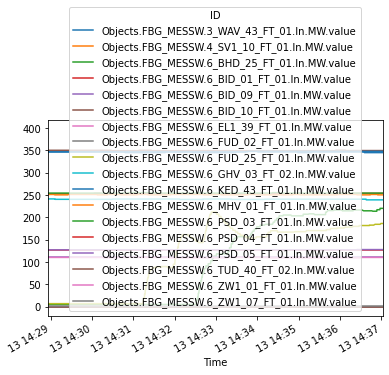

In [36]:
regExpFT='(?P<A>[a-z,A-Z,0-9,_]+)\.(?P<B>[a-z,A-Z,0-9,_]+)\.(?P<C1>[a-z,A-Z,0-9]+)_(?P<C2>[a-z,A-Z,0-9]+)_(?P<C3>[a-z,A-Z,0-9]+)_FT_(?P<C5>[a-z,A-Z,0-9]+)\.(?P<D>[a-z,A-Z,0-9,_]+)\.(?P<E>[a-z,A-Z,0-9,_]+)\.(?P<F>[a-z,A-Z,0-9,_]+)'
dfOPCPvt.filter(regex=regExpFT, axis=1).plot(xlim=('2020-11-13 14:28:56','2020-11-13 14:37:02'))